In [6]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from pathlib import Path

from going_modular.going_modular import utils, engine, data_setup, download_data

d:\Work\Coding\Machine-Learning\PyTorch\going_modular\going_modular\engine.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## Device agnostic code

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Download data

In [8]:
## As I have already downloaded data, I am not gonna download it
## but you can download it using the download_data() if you haven't downloaded it yet

## Creating datasets and dataloaders

In [9]:
## Dataset directory

dataset_dir = Path('datasets/pizza_steak_sushi')

train_dir = dataset_dir / 'train'
test_dir = dataset_dir / 'test'


## Create transform

IMG_SIZE = 224

manual_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

## create dataset

BATCH_SIZE = 32
NUM_WORKERS = 0

train_dataloader, test_dataloader, classes = data_setup.create_dataloaders(train_dir=train_dir,
                                                                           test_dir=test_dir,
                                                                           transform=manual_transform,
                                                                           batch_size=BATCH_SIZE,
                                                                           num_workers=NUM_WORKERS)

train_dataloader, test_dataloader, classes

(<torch.utils.data.dataloader.DataLoader at 0x2d0a969f4d0>,
 ['pizza', 'steak', 'sushi'])

## Visualize a single image

torch.Size([3, 224, 224]) tensor(0)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

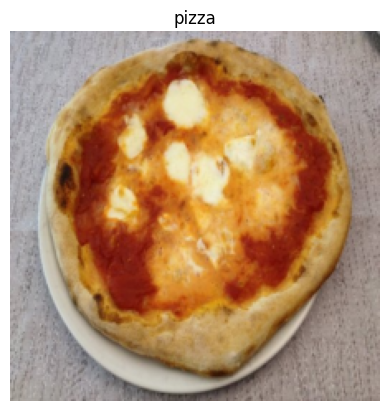

In [10]:
images, labels = next(iter(train_dataloader))

image = images[0]
label = labels[0]

print(image.shape, label)

plt.title(label=classes[label])
plt.imshow(image.permute(1, 2, 0))
plt.axis(False)

# Equation 1: Split data into patches and creating the class, position and patch embedding

## Calculating the patch embedding input and output shape by hand

In [11]:
height = 224
width = 224
color_channels = 3
patch_size = 16

num_of_patches = int((height * width) / (pow(patch_size, 2)))
print(f"Number of patchs (N) with image (height={height} and width={width}) and (patch size={patch_size}): {num_of_patches}")

Number of patchs (N) with image (height=224 and width=224) and (patch size=16): 196


In [12]:
embedding_layer_input_shape =  (height, width, color_channels)
embedding_layer_output_shape = (num_of_patches, patch_size*patch_size*color_channels)

print(f"input shape (single 2d image): {embedding_layer_input_shape}")
print(f"output shape (single 2d image flattened into patches): {embedding_layer_output_shape}")

input shape (single 2d image): (224, 224, 3)
output shape (single 2d image flattened into patches): (196, 768)


torch.Size([3, 224, 224]) tensor(0)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

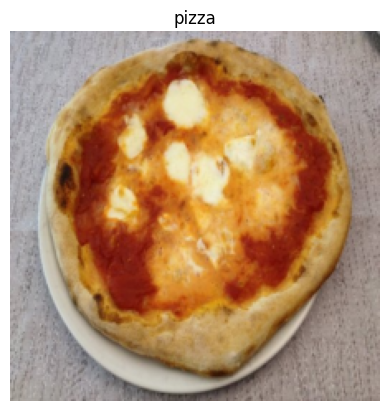

In [13]:
print(image.shape, label)

plt.title(label=classes[label])
plt.imshow(image.permute(1, 2, 0))
plt.axis(False)

## Let's visualize top row

In [14]:
image.permute(1, 2, 0)[:, :, :3].shape

torch.Size([224, 224, 3])

(np.float64(-0.5), np.float64(223.5), np.float64(15.5), np.float64(-0.5))

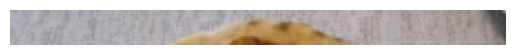

In [15]:
permuted_image = image.permute(1, 2, 0)

patch_size = 16

plt.imshow(permuted_image[:patch_size, :, :3])
plt.axis(False)

## Now create patches for the top row

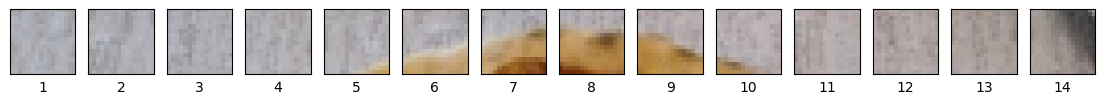

In [16]:
patch_size = 16

num_of_patches = width / patch_size

fig, axis = plt.subplots(nrows=1,
                         ncols= width // patch_size,
                         figsize=(num_of_patches, num_of_patches),
                         sharex=True,
                         sharey=True)


start_iter_patch = 0
end_iter_patch = patch_size

for i in range(0, width//patch_size):

    axis[i].imshow(permuted_image[:patch_size, start_iter_patch: end_iter_patch, :])
    axis[i].set_xlabel(i+1)
    axis[i].set_xticks([])
    axis[i].set_yticks([])
    
    start_iter_patch += patch_size
    end_iter_patch += patch_size
    

## Create whole image patches

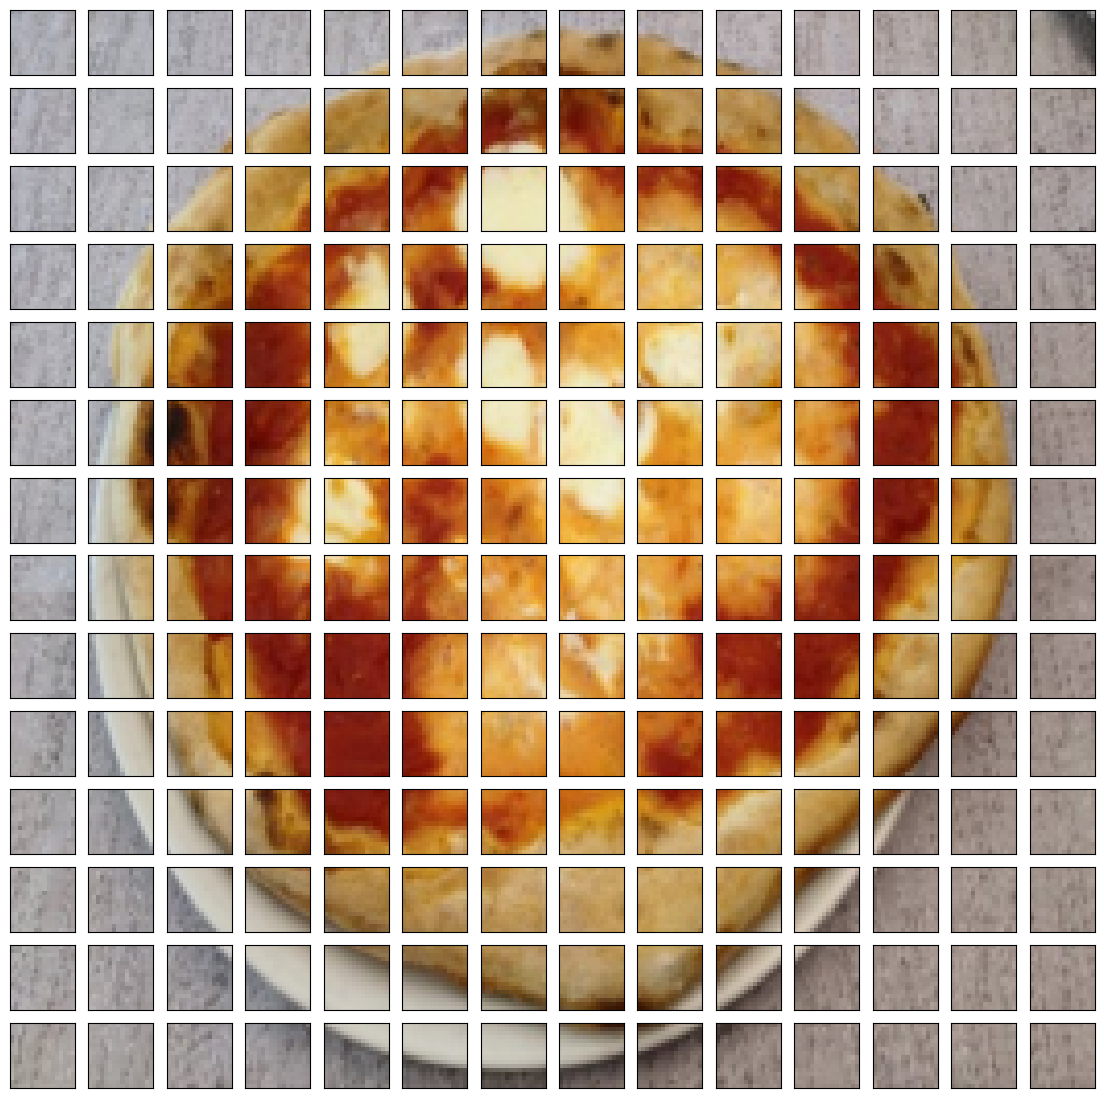

In [17]:
patch_size = 16

num_of_patches = width / patch_size

fig, axis = plt.subplots(nrows= height // patch_size,
                         ncols= width // patch_size,
                         figsize=(num_of_patches, num_of_patches),
                         sharex=True,
                         sharey=True)


height_iter_patch = 0

for i in range(0, height//patch_size):

    width_iter_patch = 0

    for j in range(0, width//patch_size):

        axis[i, j].imshow(permuted_image[height_iter_patch:height_iter_patch+patch_size, width_iter_patch: width_iter_patch+patch_size, :])
        axis[i, j].set_xticks([])
        axis[i, j].set_yticks([])
        width_iter_patch += patch_size
    
    height_iter_patch += patch_size

### What are these diffierent shapes, let's try to understand it

* So first of all we have an image with the size of [224, 224, 3] **224 height**---**224 width**---**3 channels**

* We create patches from these images and one patch size is [16, 16, 3] **16 hieght**--- **16 width**---**3 channels**

* In total we get **`196`** patches.

<details>

<summary>How to calculate patches?</summary>

---

* Divide patch height with image height

    ```python
    224 / 16 = 14
    ```

* Divide patch width with image width

    ```python
    224 / 16 = 14
    ```

* Multiply results

    ```python
    14 * 14 = 196
    ```

---

</details>
    
* After we flatten image we get this shape `[196, 768]`

* **Flatten is basically an operation in which we convert the n-dimensions into vector, data remains same only shape change**

<details>

<summary>How to calculate the faltten image shape</summary>

---

* First we have total patches `196` and we already now how to calculate it

* Secondly we have value 768 and this is came from only one patch shape of `[16*16*3]`

    ```python
    16 * 16 * 3 = 768
    ```
---

</details>

In [18]:
14*14, 16*16*3

(196, 768)

## create conv2d layer

In [19]:
patch_size = 16

conv2d = nn.Conv2d(in_channels=3,
                   out_channels=768,
                   kernel_size=patch_size,
                   stride=patch_size,
                   padding=0)

In [20]:
image_out_of_conv = conv2d((image).unsqueeze(dim=0))
image_out_of_conv.shape

torch.Size([1, 768, 14, 14])

torch.Size([1, 14, 14])

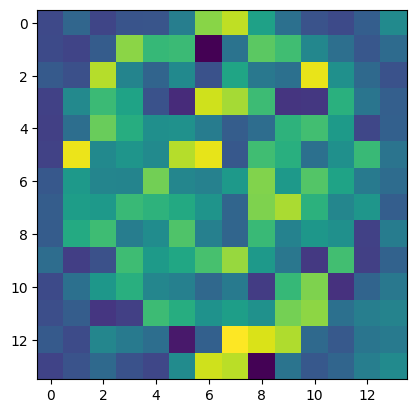

In [21]:
image_conv_feature_map = image_out_of_conv[:, 0, :, :]
plt.imshow(image_conv_feature_map.detach().numpy().squeeze())
image_conv_feature_map.shape

## Let's visualize 5 different feature maps

Showing random convolutional feature maps from indexes: [77, 528, 595, 75, 76]


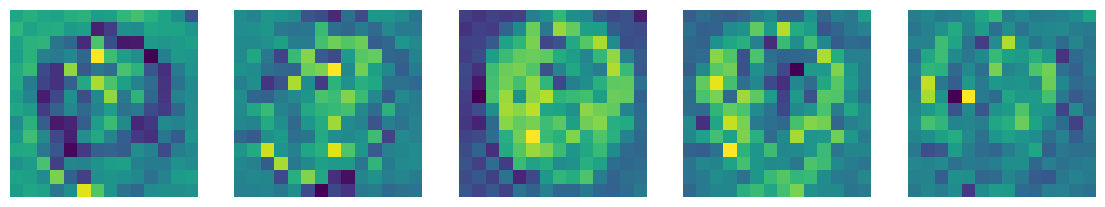

In [22]:
import random

random_idx = random.sample(range(0, 768), k=5)
print(f"Showing random convolutional feature maps from indexes: {random_idx}")

fig, axs = plt.subplots(
    nrows=1,
    ncols=len(random_idx),
    figsize=(14, 14)
)

for i, idx in enumerate(random_idx):

    image_conv_feature_map = image_out_of_conv[:, idx, :, :]
    axs[i].imshow(image_conv_feature_map.detach().numpy().squeeze())
    axs[i].axis(False)

In [23]:
image_out_of_conv.shape

torch.Size([1, 768, 14, 14])

## create faltten layer

In [24]:
## using the 2 and 3 becuase we wanna flatten the spatial dimensions of the feautre map

flatten = nn.Flatten(start_dim=2,
                     end_dim=3)


In [25]:
flatten(image_out_of_conv).permute(0, 2, 1).shape

torch.Size([1, 196, 768])

## Now put these layers together

Original image shape: torch.Size([3, 224, 224])
Image feature map shape: torch.Size([1, 768, 14, 14])
Flattened image feature map shape: torch.Size([1, 768, 196])


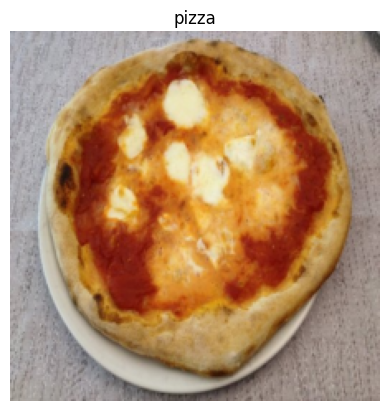

In [26]:
plt.imshow(image.permute(1, 2, 0))
plt.title(classes[label])
plt.axis(False)

print(f"Original image shape: {image.shape}")

image_out_of_conv = conv2d(image.unsqueeze(dim=0))
print(f"Image feature map shape: {image_out_of_conv.shape}")

image_out_of_conv_flattened = flatten(image_out_of_conv)
print(f"Flattened image feature map shape: {image_out_of_conv_flattened.shape}")

In [27]:
image_out_of_conv_flattened_reshaped = image_out_of_conv_flattened.permute(0, 2, 1)
image_out_of_conv_flattened_reshaped.shape

torch.Size([1, 196, 768])

## Visualize one of the flattened feature map

(np.float64(-0.5), np.float64(195.5), np.float64(0.5), np.float64(-0.5))

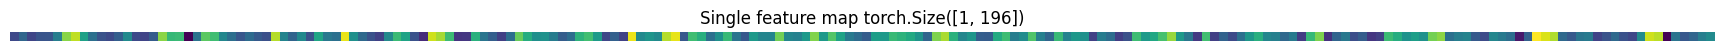

In [28]:
single_feature_map = image_out_of_conv_flattened_reshaped[:, :, 0]

plt.figure(figsize=(22, 22))
plt.title(f"Single feature map {(single_feature_map.shape)}")
plt.imshow(single_feature_map.detach().numpy())
plt.axis(False)

In [29]:
single_feature_map, single_feature_map.requires_grad, single_feature_map.shape

(tensor([[-0.1584, -0.1174, -0.1639, -0.1448, -0.1433, -0.0795,  0.0709,  0.1027,
          -0.0243, -0.1015, -0.1453, -0.1581, -0.1285, -0.0601, -0.1578, -0.1649,
          -0.1320,  0.0736,  0.0129,  0.0181, -0.2437, -0.0976,  0.0437,  0.0216,
          -0.0660, -0.1036, -0.1394, -0.1095, -0.1347, -0.1496,  0.0966, -0.0706,
          -0.1199, -0.0613, -0.1466, -0.0177, -0.0907, -0.1017,  0.1266, -0.0509,
          -0.1123, -0.1470, -0.1696, -0.0639,  0.0171, -0.0212, -0.1466, -0.1966,
           0.1123,  0.0884,  0.0197, -0.1839, -0.1810, -0.0004, -0.0949, -0.1282,
          -0.1709, -0.1055,  0.0526, -0.0048, -0.0534, -0.0493, -0.0833, -0.1310,
          -0.1064,  0.0038,  0.0241, -0.0352, -0.1623, -0.1261, -0.1676,  0.1284,
          -0.0618, -0.0435, -0.0608,  0.0971,  0.1256, -0.1381,  0.0225, -0.0017,
          -0.1020, -0.0517,  0.0154, -0.0964, -0.1382, -0.0356, -0.0687, -0.0709,
           0.0581, -0.0682, -0.0751, -0.0366,  0.0669, -0.0372,  0.0371, -0.0210,
          -0.087

## Time to create the ViT patch embedding layer into pytorch module

In [30]:
class PatchEmbedding(nn.Module):

    def __init__(self, patch_size, in_channels, out_channels, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.patcher = nn.Conv2d(in_channels=in_channels,
                           out_channels=out_channels,
                           kernel_size=patch_size,
                           stride=patch_size,
                           padding=0)
        
        self.flatten = nn.Flatten(start_dim=2,
                             end_dim=3)
        
    def forward(self, x):

        image_resolution = x.shape[-1]

        assert image_resolution % patch_size == 0, f"Image size must be divisible by patch size, image shape: {image_resolution}, patch_size: {patch_size}"

        return self.flatten(self.patcher(x)).permute(0, 2, 1)

In [31]:
patchEmbedding = PatchEmbedding(patch_size=16,
                                in_channels=3,
                                out_channels=768)

patchEmbedding

PatchEmbedding(
  (patcher): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (flatten): Flatten(start_dim=2, end_dim=3)
)

In [32]:
patch_embedding_image = patchEmbedding(image.unsqueeze(dim=0))
patch_embedding_image.shape

torch.Size([1, 196, 768])

## Now we create CLS token and put it in front of the patches

##### we are gonna use the `torch.ones()` instead of `torch.randn()` because we wanna see the process although in reality we need to create it with `torch.randn()` and improve via gradient descent and this goes for both CLS and position embedding

### Create class token

In [57]:
# number of batches = 1
print(f"Patch embedding shape: {patch_embedding_image.shape} -> [num_of_batch, num_of_tokens, embedding_dimensions_per_patch]")

batch_size =  patch_embedding_image.shape[0]

# number of dimensions are currently 768
embedding_dimension = patch_embedding_image.shape[-1]

# and as for patches we are creating one patch so we hard code it in

class_token = nn.Parameter(torch.ones(size=(batch_size, 1, embedding_dimension)),
                           requires_grad=True)

print(f"Class token: {class_token[:, :, :10]}")
print(f"Class token shape: {class_token.shape} -> [num_of_batch, num_of_tokens, embedding_dimensions_per_patch]")

Patch embedding shape: torch.Size([1, 196, 768]) -> [num_of_batch, num_of_tokens, embedding_dimensions_per_patch]
Class token: tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Class token shape: torch.Size([1, 1, 768]) -> [num_of_batch, num_of_tokens, embedding_dimensions_per_patch]


### Put class token in front of the patch embedding

In [58]:
patch_embedding_image_with_class_embedding  = torch.cat((class_token, patch_embedding_image),
                                                         dim=1)

print(patch_embedding_image_with_class_embedding)
print(f"Shape of patch embedding after putting class token in front of it: {patch_embedding_image_with_class_embedding.shape}")

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [ 0.0992, -0.2586, -0.1530,  ...,  0.1482, -0.0081, -0.6467],
         [ 0.0607, -0.2292, -0.1309,  ...,  0.1657, -0.0439, -0.6021],
         ...,
         [ 0.0432, -0.2143, -0.1165,  ...,  0.1526,  0.0127, -0.5145],
         [ 0.0428, -0.1942, -0.1265,  ...,  0.1576, -0.0518, -0.5397],
         [ 0.0536, -0.1944, -0.1302,  ...,  0.1667, -0.0160, -0.5627]]],
       grad_fn=<CatBackward0>)
Shape of patch embedding after putting class token in front of it: torch.Size([1, 197, 768])


## Now we create the position embeddings

In [59]:
print(f"Embedding dimension: {embedding_dimension}")

num_of_patches = patch_embedding_image_with_class_embedding.shape[1]

print(f"Number of patches: {num_of_patches}")
print(f"Batch size: {batch_size}")

position_embedding = nn.Parameter(torch.ones(batch_size, num_of_patches, embedding_dimension),
                                  requires_grad=True)

print(position_embedding)
print(f"Position embedding shape: {position_embedding.shape} -> [batch_size, num_of_patches, embedding_dimension]")

Embedding dimension: 768
Number of patches: 197
Batch size: 1
Parameter containing:
tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]], requires_grad=True)
Position embedding shape: torch.Size([1, 197, 768]) -> [batch_size, num_of_patches, embedding_dimension]


### Add position embeddings with patch embeddings with a prepend class token 

In [60]:
patch_and_position_embedding = patch_embedding_image_with_class_embedding + position_embedding
print(patch_and_position_embedding)
print(f"Patch embeddings, class token prepend and positional embeddings added shape: {patch_and_position_embedding.shape}")

tensor([[[2.0000, 2.0000, 2.0000,  ..., 2.0000, 2.0000, 2.0000],
         [1.0992, 0.7414, 0.8470,  ..., 1.1482, 0.9919, 0.3533],
         [1.0607, 0.7708, 0.8691,  ..., 1.1657, 0.9561, 0.3979],
         ...,
         [1.0432, 0.7857, 0.8835,  ..., 1.1526, 1.0127, 0.4855],
         [1.0428, 0.8058, 0.8735,  ..., 1.1576, 0.9482, 0.4603],
         [1.0536, 0.8056, 0.8698,  ..., 1.1667, 0.9840, 0.4373]]],
       grad_fn=<AddBackward0>)
Patch embeddings, class token prepend and positional embeddings added shape: torch.Size([1, 197, 768])


## Putting it all together from image to embedding in one cell

In [81]:
utils.set_seeds(10)

## patch_size

patch_size = 16

## get single image and store it height and width

image = next(iter(images))

height = image.shape[1]
width = image.shape[-1]

print(f"Image tensor shape: {image.shape}")

## add a batch dimension with image to make it compatible with PatchEmbedding layer

x = image.unsqueeze(dim=0)
print(f"Input image with batch dimension shape: {x.shape}")

## create patch embedding with with the patch dimesnion layer using the patch_size = 16 and embedding_dim=768

patch_embedding_layer = PatchEmbedding(patch_size=patch_size,
                                       in_channels=3,
                                       out_channels=768)

patch_embedding = patch_embedding_layer(x)

print(f"Patch embedding shape: {patch_embedding.shape}")

## create a class token

batch_size = patch_embedding.shape[0]
embedding_shape = patch_embedding.shape[-1]

class_token = nn.Parameter(torch.randn(batch_size, 1, embedding_shape),
                           requires_grad=True)

print(f"Class token embedding shape: {class_token.shape}")

## prepeding the class token to the patch embedding

patch_embedding_with_class_token = torch.cat((patch_embedding, class_token), dim=1)

print(f"Shape of the patch embedding with the class token: {patch_embedding_with_class_token.shape}")

## create a positional embedding

num_of_patches = patch_embedding_with_class_token.shape[1]

position_embedding = nn.Parameter(torch.randn(batch_size, num_of_patches, embedding_shape),
                                  requires_grad=True)

print(f"Shape of the position embeddings: {position_embedding.shape}")

## adding the position embedding to the class token

patch_class_token_and_position_embedding = patch_embedding_with_class_token + position_embedding
print(f"Shape of patch, class token and position embedding: {patch_class_token_and_position_embedding.shape}")

Image tensor shape: torch.Size([3, 224, 224])
Input image with batch dimension shape: torch.Size([1, 3, 224, 224])
Patch embedding shape: torch.Size([1, 196, 768])
Class token embedding shape: torch.Size([1, 1, 768])
Shape of the patch embedding with the class token: torch.Size([1, 197, 768])
Shape of the position embeddings: torch.Size([1, 197, 768])
Shape of patch, class token and position embedding: torch.Size([1, 197, 768])


# Equation 2: Multi-Head Attention (MSA)